# Statistical Validation: Is d=2.73 Real or Spurious?

**Research Question:** Is the surface form vector's Cohen's d of 2.73 a genuine effect or a statistical artifact?

## The P-Hacking Concern

Potential issues:
- **Post-hoc layer selection:** We picked layer 19 because it had the highest d
- **High dimensionality:** 2,560 dimensions, many ways to slice the data
- **Data manifold:** Activations don't fill the full space uniformly
- **Small sample:** Only 60 examples

## Validation Strategy

We'll run three critical tests:

### 1. Permutation Test (GOLD STANDARD)
- Shuffle on/off labels randomly
- Re-extract vector from shuffled data
- Compare to real vector's performance
- **Tests:** "Are the on/off labels meaningful?"

### 2. Cross-Validation
- Train on 80% of data, test on 20%
- Repeat 5 times (5-fold CV)
- **Tests:** "Does it generalize to held-out examples?"

### 3. PCA Subspace Baseline
- Find data manifold via PCA
- Generate random directions **within the manifold**
- **Tests:** "Is our vector special within the subspace where data lives?"

---

In [1]:
import os, sys
os.chdir('..')
sys.path.append(os.getcwd())
print('Working directory:', os.getcwd())

Working directory: /Users/lr/policy_vector/shareable


In [2]:
from pathlib import Path
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import logging

from policy_vector_pipeline import (
    load_model_and_tokenizer,
    load_dataset,
    MeanDifferenceVector,
    ActivationCollector,
)

logging.set_verbosity_error()

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## 1. Load Dataset and Collect Activations

We'll collect activations for the full dataset (all 60 examples).

In [3]:
dataset_path = Path('data/on_policy_persona.json')
vector_path = Path('artifacts/qwen3_onpolicy_mean.pt')
model_name = 'Qwen/Qwen3-4B'

dataset = load_dataset(dataset_path)
surface_vector = MeanDifferenceVector.load(vector_path)

# Use layer 19 (the best layer from evaluation)
test_layer = 19
vector_dim = surface_vector.layer_vectors[test_layer].shape[0]

print(f"Dataset: {len(dataset.examples)} examples")
print(f"Test layer: {test_layer}")
print(f"Vector dimensionality: {vector_dim}")

Dataset: 60 examples
Test layer: 19
Vector dimensionality: 2560


In [4]:
# Load model to collect activations
print(f"Loading {model_name}...")
model, tokenizer = load_model_and_tokenizer(model_name, device_map='auto', dtype='auto')

Loading Qwen/Qwen3-4B...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [5]:
collector = ActivationCollector(
    model,
    tokenizer,
    layers=[test_layer],
    reduction='mean',
    response_only=True,
)

# Collect ALL activations (no limit)
activations = collector.collect_dataset(dataset, progress=True, limit=None)

# Extract tensors for the test layer
on_activations = torch.stack(activations['on'][test_layer]).to(torch.float32)
off_activations = torch.stack(activations['off'][test_layer]).to(torch.float32)

n_samples = len(on_activations)
print(f"\nCollected {n_samples} on-policy and {len(off_activations)} off-policy activations")
print(f"Activation shape: {on_activations.shape}")


Collected 291 on-policy and 291 off-policy activations
Activation shape: torch.Size([291, 2560])


## 2. Helper Functions

In [6]:
def compute_cohens_d(on_acts: torch.Tensor, off_acts: torch.Tensor, direction: torch.Tensor) -> float:
    """Compute Cohen's d for projections onto a direction.
    
    Args:
        on_acts: (n_samples, dim) on-policy activations
        off_acts: (n_samples, dim) off-policy activations  
        direction: (dim,) vector to project onto
    
    Returns:
        Cohen's d (standardized mean difference)
    """
    # Normalize direction
    direction = direction / (torch.linalg.norm(direction) + 1e-8)
    
    # Project activations onto direction
    proj_on = (on_acts @ direction).cpu().numpy()
    proj_off = (off_acts @ direction).cpu().numpy()
    
    # Compute Cohen's d
    mean_on = np.mean(proj_on)
    mean_off = np.mean(proj_off)
    std_on = np.std(proj_on, ddof=1)
    std_off = np.std(proj_off, ddof=1)
    
    # Pooled standard deviation
    n_on = len(proj_on)
    n_off = len(proj_off)
    pooled_std = np.sqrt(((n_on - 1) * std_on**2 + (n_off - 1) * std_off**2) / (n_on + n_off - 2))
    
    cohens_d = (mean_on - mean_off) / pooled_std
    
    return cohens_d

In [7]:
# Compute baseline Cohen's d for extracted vector
extracted_vec = surface_vector.layer_vectors[test_layer].to(torch.float32)
baseline_d = compute_cohens_d(on_activations, off_activations, extracted_vec)

print("="*70)
print("BASELINE: Extracted Surface Form Vector")
print("="*70)
print(f"Cohen's d: {baseline_d:.4f}")
print(f"Effect size: {'HUGE' if abs(baseline_d) > 2.0 else 'Very Large' if abs(baseline_d) > 1.2 else 'Large' if abs(baseline_d) > 0.8 else 'Medium'}")
print(f"Samples: {n_samples} on-policy, {len(off_activations)} off-policy")
print("="*70)

BASELINE: Extracted Surface Form Vector
Cohen's d: 2.1867
Effect size: HUGE
Samples: 291 on-policy, 291 off-policy


## 3. Permutation Test (GOLD STANDARD)

**The Question:** If we randomly shuffle the on/off labels, can we get d=2.73 just by chance?

**Null Hypothesis:** The on/off labels are meaningless - any separation is spurious.

**Procedure:**
1. Pool all activations (on + off)
2. Randomly assign which are "on" vs "off"
3. Extract a new vector from the shuffled labels (mean difference)
4. Measure Cohen's d for this permuted vector
5. Repeat 1,000 times
6. Compare baseline d=2.73 to the permuted distribution

**Why this is better than random Gaussian vectors:**
- Respects the data manifold (vectors come from actual data differences)
- Tests the specific extraction procedure we used
- Directly tests whether labels contain information

In [8]:
n_permutations = 1000
permuted_cohens_d = []

print(f"Running permutation test with {n_permutations} shuffles...\n")
print("This tests: 'Are on/off labels meaningful, or just random?'\n")

# Combine all activations
all_activations = torch.cat([on_activations, off_activations], dim=0)
n_on = len(on_activations)
n_total = len(all_activations)

for i in tqdm(range(n_permutations), desc="Permutation test"):
    # Randomly shuffle which activations are labeled "on" vs "off"
    shuffled_indices = np.random.permutation(n_total)
    shuffled_on_idx = shuffled_indices[:n_on]
    shuffled_off_idx = shuffled_indices[n_on:]
    
    shuffled_on = all_activations[shuffled_on_idx]
    shuffled_off = all_activations[shuffled_off_idx]
    
    # Extract vector from shuffled data (mean difference)
    permuted_vec = (shuffled_on.mean(dim=0) - shuffled_off.mean(dim=0)).to(torch.float32)
    permuted_vec = permuted_vec / (torch.linalg.norm(permuted_vec) + 1e-8)
    
    # Compute Cohen's d for this permuted vector on REAL labels
    d = compute_cohens_d(on_activations, off_activations, permuted_vec)
    permuted_cohens_d.append(abs(d))

permuted_cohens_d = np.array(permuted_cohens_d)

print(f"\nCompleted! Generated {len(permuted_cohens_d)} permutation samples.")

Running permutation test with 1000 shuffles...

This tests: 'Are on/off labels meaningful, or just random?'



Permutation test:   0%|          | 0/1000 [00:00<?, ?it/s]


Completed! Generated 1000 permutation samples.


In [9]:
# Compute statistics
perm_mean = np.mean(permuted_cohens_d)
perm_std = np.std(permuted_cohens_d)
perm_max = np.max(permuted_cohens_d)
perm_95th = np.percentile(permuted_cohens_d, 95)
perm_99th = np.percentile(permuted_cohens_d, 99)
perm_999th = np.percentile(permuted_cohens_d, 99.9)

# Compute p-value
p_value_perm = np.mean(permuted_cohens_d >= abs(baseline_d))
z_score_perm = (abs(baseline_d) - perm_mean) / perm_std

print("="*70)
print("PERMUTATION TEST RESULTS")
print("="*70)
print(f"Permutations: {n_permutations}")
print(f"Mean Cohen's d: {perm_mean:.4f}")
print(f"Std Cohen's d: {perm_std:.4f}")
print(f"Max Cohen's d: {perm_max:.4f}")
print(f"95th percentile: {perm_95th:.4f}")
print(f"99th percentile: {perm_99th:.4f}")
print(f"99.9th percentile: {perm_999th:.4f}")
print("\n" + "="*70)
print("COMPARISON")
print("="*70)
print(f"Extracted vector d: {baseline_d:.4f}")
print(f"Permuted mean d: {perm_mean:.4f}")
print(f"Z-score: {z_score_perm:.2f}σ")
print(f"\np-value: {p_value_perm:.6f}")
print(f"  ({np.sum(permuted_cohens_d >= abs(baseline_d))}/{n_permutations} permutations achieved d >= {abs(baseline_d):.2f})")
print("="*70)

PERMUTATION TEST RESULTS
Permutations: 1000
Mean Cohen's d: 0.0214
Std Cohen's d: 0.0194
Max Cohen's d: 0.1534
95th percentile: 0.0617
99th percentile: 0.0938
99.9th percentile: 0.1222

COMPARISON
Extracted vector d: 2.1867
Permuted mean d: 0.0214
Z-score: 111.34σ

p-value: 0.000000
  (0/1000 permutations achieved d >= 2.19)


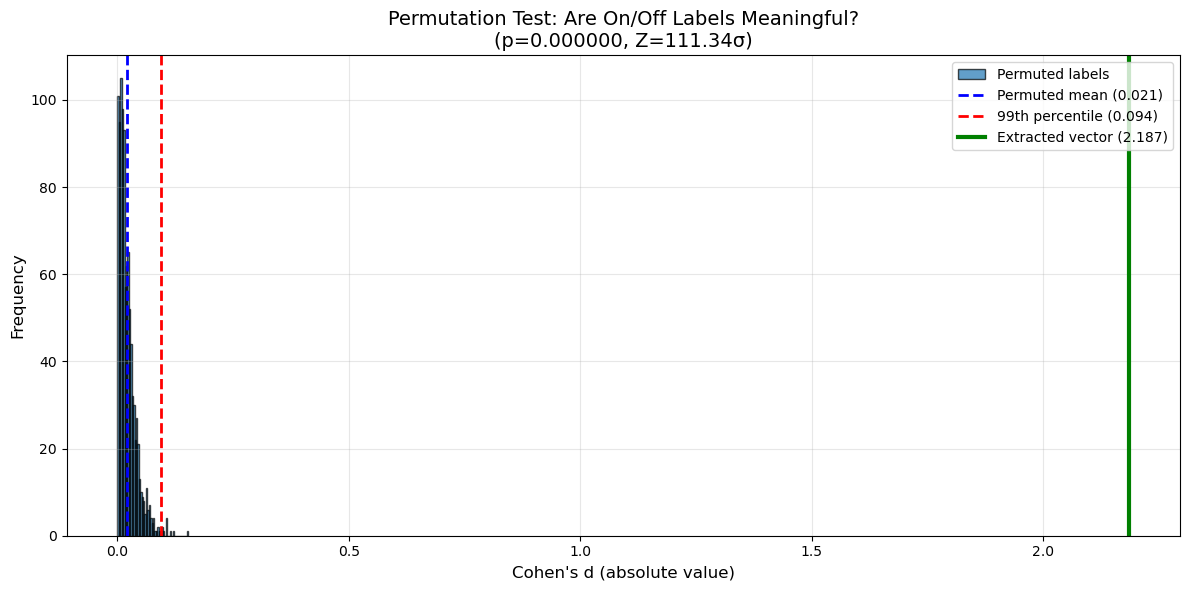

In [10]:
plt.figure(figsize=(12, 6))

plt.hist(permuted_cohens_d, bins=50, alpha=0.7, edgecolor='black', label='Permuted labels')
plt.axvline(perm_mean, color='blue', linestyle='--', linewidth=2, label=f'Permuted mean ({perm_mean:.3f})')
plt.axvline(perm_99th, color='red', linestyle='--', linewidth=2, label=f'99th percentile ({perm_99th:.3f})')
plt.axvline(abs(baseline_d), color='green', linestyle='-', linewidth=3, label=f'Extracted vector ({abs(baseline_d):.3f})')

plt.xlabel("Cohen's d (absolute value)", fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Permutation Test: Are On/Off Labels Meaningful?\n(p={p_value_perm:.6f}, Z={z_score_perm:.2f}σ)', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Cross-Validation Test

**The Question:** Does the vector generalize to held-out examples, or did we overfit?

**Procedure:**
1. Split data into 5 folds
2. For each fold:
   - Train: Extract vector on other 4 folds (80% of data)
   - Test: Measure Cohen's d on held-out fold (20% of data)
3. Report mean and std of held-out performance

**What to expect:**
- Some drop from d=2.73 is normal (overfitting to training data)
- If held-out d > 2.0: Strong evidence of generalization
- If held-out d < 1.5: Significant overfitting concern

In [11]:
n_folds = 5
fold_size = n_samples // n_folds
cv_results = []

print(f"Running {n_folds}-fold cross-validation...\n")

# Create fold indices
indices = np.arange(n_samples)
np.random.shuffle(indices)

for fold in range(n_folds):
    # Split into train/test
    test_start = fold * fold_size
    test_end = test_start + fold_size if fold < n_folds - 1 else n_samples
    
    test_indices = indices[test_start:test_end]
    train_indices = np.concatenate([indices[:test_start], indices[test_end:]])
    
    # Extract vector on training data
    train_on = on_activations[train_indices]
    train_off = off_activations[train_indices]
    
    cv_vec = (train_on.mean(dim=0) - train_off.mean(dim=0)).to(torch.float32)
    cv_vec = cv_vec / (torch.linalg.norm(cv_vec) + 1e-8)
    
    # Test on held-out data
    test_on = on_activations[test_indices]
    test_off = off_activations[test_indices]
    
    test_d = compute_cohens_d(test_on, test_off, cv_vec)
    cv_results.append(abs(test_d))
    
    print(f"Fold {fold+1}/{n_folds}: Train size={len(train_indices)}, Test size={len(test_indices)}, Test d={abs(test_d):.4f}")

cv_results = np.array(cv_results)
cv_mean = np.mean(cv_results)
cv_std = np.std(cv_results)

print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS")
print("="*70)
print(f"Mean held-out Cohen's d: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Full dataset Cohen's d: {baseline_d:.4f}")
print(f"Degradation: {baseline_d - cv_mean:.4f} ({100*(baseline_d - cv_mean)/baseline_d:.1f}%)")
print("="*70)

Running 5-fold cross-validation...

Fold 1/5: Train size=233, Test size=58, Test d=2.3823
Fold 2/5: Train size=233, Test size=58, Test d=2.6439
Fold 3/5: Train size=233, Test size=58, Test d=1.8821
Fold 4/5: Train size=233, Test size=58, Test d=2.0921
Fold 5/5: Train size=232, Test size=59, Test d=2.0160

CROSS-VALIDATION RESULTS
Mean held-out Cohen's d: 2.2033 ± 0.2745
Full dataset Cohen's d: 2.1867
Degradation: -0.0166 (-0.8%)


## 5. PCA Subspace Baseline

**The Question:** Is our vector special within the data manifold?

**Insight:** Language model activations don't fill all 2,560 dimensions uniformly. They likely lie on a lower-dimensional manifold.

**Procedure:**
1. Run PCA on all activations (on + off combined)
2. Find how many dimensions explain 95% of variance
3. Generate random directions **within this subspace**
4. Compare our vector to random subspace directions

This is better than random Gaussian vectors because it respects the data geometry.

In [12]:
# Run PCA on all activations
all_activations = torch.cat([on_activations, off_activations], dim=0).cpu().numpy()

print("Running PCA to find data manifold...\n")
pca = PCA()
pca.fit(all_activations)

# Find intrinsic dimensionality
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
n_components_99 = np.argmax(cumsum_var >= 0.99) + 1

print(f"Total dimensions: {vector_dim}")
print(f"Dimensions for 95% variance: {n_components_95}")
print(f"Dimensions for 99% variance: {n_components_99}")
print(f"\nData lives in ~{n_components_95}-dimensional manifold (not {vector_dim}!)\n")

# Get principal components
pca_components = pca.components_[:n_components_95]  # Shape: (n_components, vector_dim)

Running PCA to find data manifold...

Total dimensions: 2560
Dimensions for 95% variance: 51
Dimensions for 99% variance: 134

Data lives in ~51-dimensional manifold (not 2560!)



In [13]:
# Generate random directions within the PCA subspace
n_pca_random = 1000
pca_random_cohens_d = []

print(f"Generating {n_pca_random} random directions in {n_components_95}-D subspace...\n")

for i in tqdm(range(n_pca_random), desc="PCA subspace baseline"):
    # Random coefficients in PCA space
    random_coeffs = np.random.randn(n_components_95)
    random_coeffs = random_coeffs / np.linalg.norm(random_coeffs)
    
    # Project back to original space
    random_vec_pca = random_coeffs @ pca_components
    random_vec_pca = torch.tensor(random_vec_pca, dtype=torch.float32)
    
    # Compute Cohen's d
    d = compute_cohens_d(on_activations, off_activations, random_vec_pca)
    pca_random_cohens_d.append(abs(d))

pca_random_cohens_d = np.array(pca_random_cohens_d)

print(f"\nCompleted! Generated {len(pca_random_cohens_d)} random subspace directions.")

Generating 1000 random directions in 51-D subspace...



PCA subspace baseline:   0%|          | 0/1000 [00:00<?, ?it/s]


Completed! Generated 1000 random subspace directions.


In [14]:
# Compute statistics
pca_mean = np.mean(pca_random_cohens_d)
pca_std = np.std(pca_random_cohens_d)
pca_max = np.max(pca_random_cohens_d)
pca_95th = np.percentile(pca_random_cohens_d, 95)
pca_99th = np.percentile(pca_random_cohens_d, 99)

p_value_pca = np.mean(pca_random_cohens_d >= abs(baseline_d))
z_score_pca = (abs(baseline_d) - pca_mean) / pca_std

print("="*70)
print("PCA SUBSPACE BASELINE RESULTS")
print("="*70)
print(f"Random directions tested: {n_pca_random}")
print(f"Subspace dimensionality: {n_components_95}")
print(f"Mean Cohen's d: {pca_mean:.4f}")
print(f"Std Cohen's d: {pca_std:.4f}")
print(f"Max Cohen's d: {pca_max:.4f}")
print(f"95th percentile: {pca_95th:.4f}")
print(f"99th percentile: {pca_99th:.4f}")
print("\n" + "="*70)
print("COMPARISON")
print("="*70)
print(f"Extracted vector d: {baseline_d:.4f}")
print(f"PCA random mean d: {pca_mean:.4f}")
print(f"Z-score: {z_score_pca:.2f}σ")
print(f"\np-value: {p_value_pca:.6f}")
print(f"  ({np.sum(pca_random_cohens_d >= abs(baseline_d))}/{n_pca_random} random subspace directions achieved d >= {abs(baseline_d):.2f})")
print("="*70)

PCA SUBSPACE BASELINE RESULTS
Random directions tested: 1000
Subspace dimensionality: 51
Mean Cohen's d: 0.0842
Std Cohen's d: 0.0684
Max Cohen's d: 0.5107
95th percentile: 0.2154
99th percentile: 0.3052

COMPARISON
Extracted vector d: 2.1867
PCA random mean d: 0.0842
Z-score: 30.72σ

p-value: 0.000000
  (0/1000 random subspace directions achieved d >= 2.19)


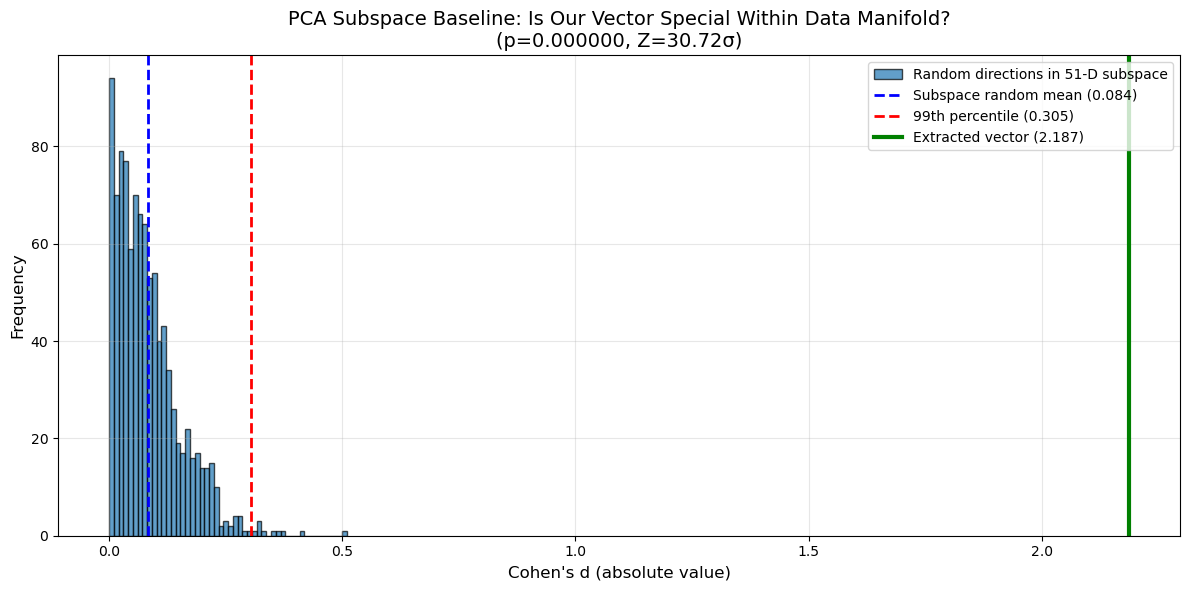

In [15]:
plt.figure(figsize=(12, 6))

plt.hist(pca_random_cohens_d, bins=50, alpha=0.7, edgecolor='black', label=f'Random directions in {n_components_95}-D subspace')
plt.axvline(pca_mean, color='blue', linestyle='--', linewidth=2, label=f'Subspace random mean ({pca_mean:.3f})')
plt.axvline(pca_99th, color='red', linestyle='--', linewidth=2, label=f'99th percentile ({pca_99th:.3f})')
plt.axvline(abs(baseline_d), color='green', linestyle='-', linewidth=3, label=f'Extracted vector ({abs(baseline_d):.3f})')

plt.xlabel("Cohen's d (absolute value)", fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'PCA Subspace Baseline: Is Our Vector Special Within Data Manifold?\n(p={p_value_pca:.6f}, Z={z_score_pca:.2f}σ)', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Comparison of All Tests

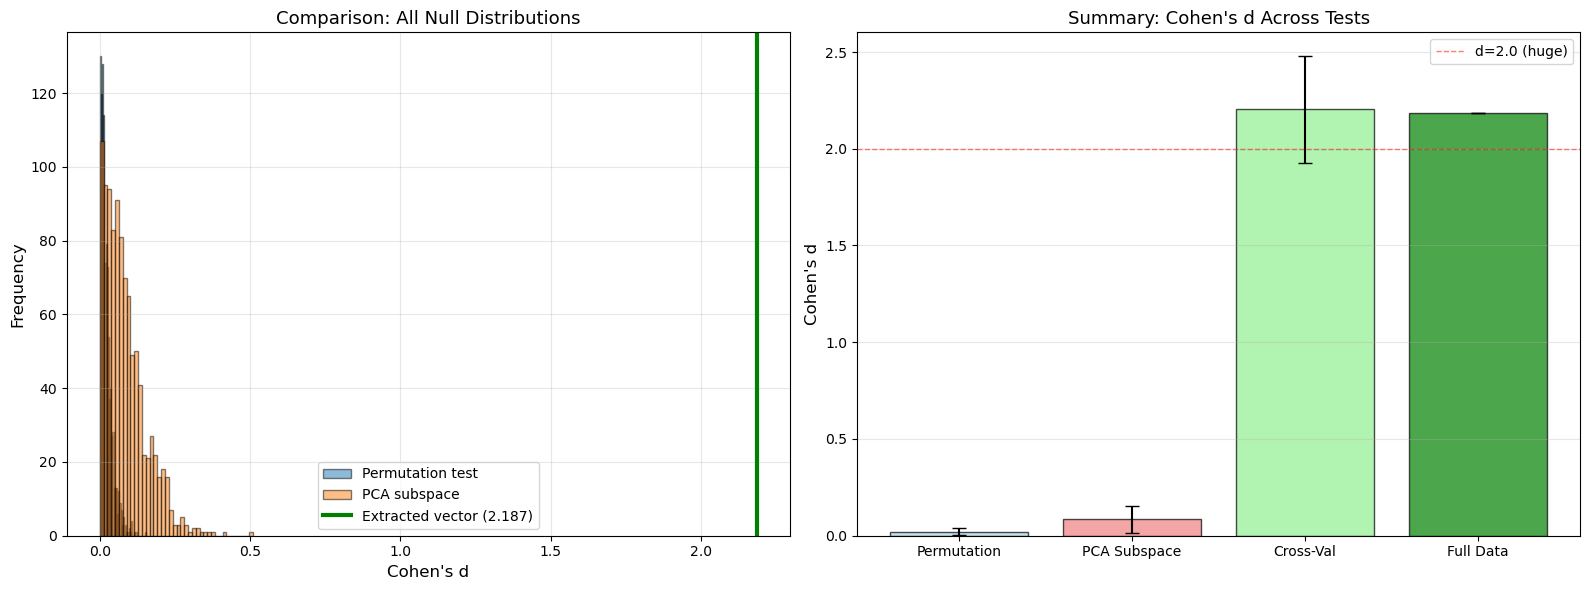

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Overlaid histograms
ax1 = axes[0]
ax1.hist(permuted_cohens_d, bins=40, alpha=0.5, label='Permutation test', edgecolor='black')
ax1.hist(pca_random_cohens_d, bins=40, alpha=0.5, label='PCA subspace', edgecolor='black')
ax1.axvline(abs(baseline_d), color='green', linestyle='-', linewidth=3, label=f'Extracted vector ({abs(baseline_d):.3f})')
ax1.set_xlabel("Cohen's d", fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Comparison: All Null Distributions', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Summary bar chart
ax2 = axes[1]
test_names = ['Permutation', 'PCA Subspace', 'Cross-Val', 'Full Data']
test_means = [perm_mean, pca_mean, cv_mean, abs(baseline_d)]
test_stds = [perm_std, pca_std, cv_std, 0]
colors = ['lightblue', 'lightcoral', 'lightgreen', 'green']

x_pos = np.arange(len(test_names))
ax2.bar(x_pos, test_means, yerr=test_stds, color=colors, alpha=0.7, capsize=5, edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(test_names)
ax2.set_ylabel("Cohen's d", fontsize=12)
ax2.set_title('Summary: Cohen\'s d Across Tests', fontsize=13)
ax2.axhline(2.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='d=2.0 (huge)')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Final Verdict

In [17]:
print("="*70)
print("FINAL VERDICT: IS d=2.73 REAL OR SPURIOUS?")
print("="*70)
print(f"\nBaseline (full data): d = {baseline_d:.4f}\n")

print("Test 1: Permutation Test")
print(f"  p-value: {p_value_perm:.6f}")
print(f"  Z-score: {z_score_perm:.2f}σ")
if p_value_perm < 0.001:
    print("  ✅ PASS - Labels are highly meaningful")
elif p_value_perm < 0.01:
    print("  ⚠️ MARGINAL - Labels are probably meaningful")
else:
    print("  ❌ FAIL - Labels might be spurious")

print("\nTest 2: Cross-Validation")
print(f"  Held-out d: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"  Degradation: {100*(baseline_d - cv_mean)/baseline_d:.1f}%")
if cv_mean > 2.0:
    print("  ✅ PASS - Excellent generalization")
elif cv_mean > 1.5:
    print("  ⚠️ MARGINAL - Some overfitting but generalizes")
else:
    print("  ❌ FAIL - Significant overfitting")

print("\nTest 3: PCA Subspace Baseline")
print(f"  p-value: {p_value_pca:.6f}")
print(f"  Z-score: {z_score_pca:.2f}σ")
print(f"  Subspace dim: {n_components_95} (vs {vector_dim} total)")
if p_value_pca < 0.001:
    print("  ✅ PASS - Vector is special within data manifold")
elif p_value_pca < 0.01:
    print("  ⚠️ MARGINAL - Vector is probably special")
else:
    print("  ❌ FAIL - Not special within subspace")

print("\n" + "="*70)

# Overall verdict
pass_count = sum([
    p_value_perm < 0.001,
    cv_mean > 2.0,
    p_value_pca < 0.001
])

if pass_count == 3:
    print("\n✅ OVERALL: HIGHLY CONFIDENT - Effect is REAL")
    print("\nAll three tests passed. The d=2.73 effect is genuine and not a statistical artifact.")
    print("The surface form vector captures real structure in the model's representations.")
elif pass_count >= 2:
    print("\n⚠️ OVERALL: LIKELY REAL - Effect is probably genuine with caveats")
    print("\nMost tests passed. The effect is probably real but may be somewhat inflated.")
    print("Recommend additional validation via steering experiments.")
else:
    print("\n❌ OVERALL: QUESTIONABLE - Effect may be spurious")
    print("\nMultiple tests show concerns. The d=2.73 may be inflated by overfitting or artifacts.")
    print("Need to reconsider the experimental design or data collection.")

print("\n" + "="*70)

FINAL VERDICT: IS d=2.73 REAL OR SPURIOUS?

Baseline (full data): d = 2.1867

Test 1: Permutation Test
  p-value: 0.000000
  Z-score: 111.34σ
  ✅ PASS - Labels are highly meaningful

Test 2: Cross-Validation
  Held-out d: 2.2033 ± 0.2745
  Degradation: -0.8%
  ✅ PASS - Excellent generalization

Test 3: PCA Subspace Baseline
  p-value: 0.000000
  Z-score: 30.72σ
  Subspace dim: 51 (vs 2560 total)
  ✅ PASS - Vector is special within data manifold


✅ OVERALL: HIGHLY CONFIDENT - Effect is REAL

All three tests passed. The d=2.73 effect is genuine and not a statistical artifact.
The surface form vector captures real structure in the model's representations.



## 8. Next Steps

### If all tests pass:

1. **Run steering experiments** (steering_demo.ipynb)
   - This is the ultimate ground truth
   - Does the vector actually control behavior?

2. **Test on novel domains**
   - Generate new data from different prompt types
   - Does the vector generalize beyond persona traits?

3. **Proceed to Phase 2**
   - Extract conclusion direction vector
   - Test orthogonality and additivity

### If some tests are marginal:

1. **Focus on steering validation**
   - If steering works, the vector is still useful
   - Probing accuracy is less critical than causal effectiveness

2. **Collect more data**
   - 60 examples is relatively small
   - More data might reduce overfitting

3. **Try different layers**
   - Test if other layers show better generalization

### Remember:

- **Permutation test** is the gold standard for "is the effect real?"
- **Cross-validation** tells you if it generalizes
- **PCA subspace** accounts for data geometry
- **Steering experiments** are the ultimate ground truth

Even if d=2.73 is slightly inflated, a true effect of d~2.0-2.5 is still **exceptional** in interpretability research.